# NB_03_perception_modules_demo - Perception Modules - Single-Frame Demo

**Purpose.** Run every perception module in isolation on one RGB frame and visualise the outputs side by side: climate classifier, E2E risk predictor, road segmentation, YOLO obstacle detection, depth estimation, SAM2 dashboard mask, and phase-correlation flow.

**Inputs.** one (or two consecutive) RGB frames from a dataset, the perception checkpoints under MIREIA/models/.

**Outputs.** a 2x4 visual grid plus per-module overlays; useful for sanity-checking checkpoint integrity.

**How to run.** Set IMAGE_PATH in the Configuration section, then run top-to-bottom. Each module cell is independent - skip any you don't need.

**Position in the workflow.** Reference demo for the Model 2 perception zoo (Chapter 5 of the thesis).


In [ ]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import torch
from PIL import Image
from torchvision import transforms

from MIREIA.config import Config
from MIREIA.perception import (
    DepthAnythingV2Estimator,
    Sam2DashboardSegmenter,
    YoloObstacleDetector,
    create_environment_classifier_predictor,
    create_streaming_predictor,
    load_road_segmentation_model,
)

## Configuration

Set the image path and device here. All subsequent cells pick these up automatically.

In [ ]:
IMAGE_PATH = Path(r"T:\TFG\MIREIA\scenarios\03A_WetNoon_Town05_HighVol\dataset\images\rgb_000190.png")
# Set to None to auto-pick the next numbered frame.
IMAGE2_OVERRIDE_PATH = Path(r"T:\TFG\MIREIA\scenarios\03A_WetNoon_Town05_HighVol\dataset\images\rgb_000195.png")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

CHECKPOINTS = {
    "climate": Path(Config.PATH_TO_MODELS) / "environment_multitask_checkpoint.pt",
    "e2e": Path(Config.PATH_TO_MODELS) / "e2e_risk_checkpoint.pt",
    "road_seg": Path(Config.PATH_TO_MODELS) / "road_segmentation_multitask_checkpoint.pt",
    "yolo": Path(Config.PATH_TO_MODELS) / "yolo11s.pt",
    "depth": Path(Config.PATH_TO_MODELS) / "depth_anything_v2_vits.pth",
    "sam2": Path(Config.PATH_TO_MODELS) / "sam2.1_hiera_small.pt",
}

if not IMAGE_PATH.is_file():
    raise FileNotFoundError(f"Image not found: {IMAGE_PATH}")

for name, path in CHECKPOINTS.items():
    if not path.is_file():
        print(f"[missing checkpoint] {name}: {path}")

## Load Images

In [ ]:
def _resolve_second_frame(image_path: Path, explicit_second: Path | None) -> Path:
    if explicit_second is not None:
        if not explicit_second.is_file():
            raise FileNotFoundError(f"Second image not found: {explicit_second}")
        return explicit_second

    match = re.match(r"^(.*?)(\d+)$", image_path.stem)
    if match:
        prefix, digits = match.groups()
        candidate = image_path.with_name(
            f"{prefix}{int(digits) + 1:0{len(digits)}d}{image_path.suffix}"
        )
        if candidate.is_file():
            return candidate

    return image_path


IMAGE2_PATH = _resolve_second_frame(
    IMAGE_PATH,
    Path(IMAGE2_OVERRIDE_PATH) if IMAGE2_OVERRIDE_PATH else None,
)

with Image.open(IMAGE_PATH) as _img:
    IMAGE_RGB = _img.convert("RGB")
with Image.open(IMAGE2_PATH) as _img2:
    IMAGE2_RGB = _img2.convert("RGB")

if IMAGE_RGB.size != IMAGE2_RGB.size:
    raise ValueError(
        f"Both images must have the same size. Got {IMAGE_RGB.size} and {IMAGE2_RGB.size}"
    )

IMAGE_NP = np.asarray(IMAGE_RGB)

print(f"Image 1: {IMAGE_PATH}")
print(f"Image 2: {IMAGE2_PATH}")
if IMAGE2_PATH == IMAGE_PATH:
    print("[info] Using the same frame twice.")

## Road Mask Postprocessing Helpers

In [ ]:
def _disk_structure(radius: int = 3) -> np.ndarray:
    yy, xx = np.ogrid[-radius : radius + 1, -radius : radius + 1]
    return (yy * yy + xx * xx) <= (radius * radius)


def _binary_dilate(mask: np.ndarray, radius: int = 3) -> np.ndarray:
    mask_bool = np.asarray(mask, dtype=bool)
    if mask_bool.size == 0:
        return mask_bool

    structure = _disk_structure(radius=radius)

    try:
        from scipy.ndimage import binary_dilation
        return binary_dilation(mask_bool, structure=structure)
    except Exception:
        pad_y, pad_x = radius, radius
        padded = np.pad(mask_bool, ((pad_y, pad_y), (pad_x, pad_x)), mode="constant", constant_values=False)
        height, width = mask_bool.shape
        dilated = np.zeros((height, width), dtype=bool)
        ys, xs = np.nonzero(structure)
        for yk, xk in zip(ys, xs):
            dilated |= padded[yk : yk + height, xk : xk + width]
        return dilated


def _largest_connected_component(mask: np.ndarray) -> np.ndarray:
    mask_bool = np.asarray(mask, dtype=bool)
    if mask_bool.size == 0 or not mask_bool.any():
        return np.zeros_like(mask_bool, dtype=bool)

    try:
        from scipy.ndimage import label
        labels, num_labels = label(mask_bool, structure=np.ones((3, 3), dtype=np.uint8))
        if num_labels == 0:
            return np.zeros_like(mask_bool, dtype=bool)
        counts = np.bincount(labels.ravel())
        counts[0] = 0
        return labels == int(np.argmax(counts))
    except Exception:
        height, width = mask_bool.shape
        visited = np.zeros_like(mask_bool, dtype=bool)
        neighbors = [(-1,-1),(-1,0),(-1,1),(0,-1),(0,1),(1,-1),(1,0),(1,1)]
        best_component: list[tuple[int, int]] = []

        for y in range(height):
            for x in range(width):
                if not mask_bool[y, x] or visited[y, x]:
                    continue
                stack = [(y, x)]
                visited[y, x] = True
                component: list[tuple[int, int]] = []
                while stack:
                    cy, cx = stack.pop()
                    component.append((cy, cx))
                    for dy, dx in neighbors:
                        ny, nx = cy + dy, cx + dx
                        if 0 <= ny < height and 0 <= nx < width and not visited[ny, nx] and mask_bool[ny, nx]:
                            visited[ny, nx] = True
                            stack.append((ny, nx))
                if len(component) > len(best_component):
                    best_component = component

        out = np.zeros_like(mask_bool, dtype=bool)
        for py, px in best_component:
            out[py, px] = True
        return out


def _postprocess_road_mask(mask: np.ndarray, dilation_radius: int = 3) -> np.ndarray:
    return _largest_connected_component(_binary_dilate(mask, radius=dilation_radius))

## Inference

Each cell below runs one model independently. Missing checkpoints are silently skipped.

### Climate Classifier

In [ ]:
climate_prediction = None

if CHECKPOINTS["climate"].is_file():
    try:
        climate_predictor = create_environment_classifier_predictor(
            checkpoint_path=str(CHECKPOINTS["climate"]),
            device=DEVICE,
        )
        climate_prediction = climate_predictor.predict_from_image_path(str(IMAGE_PATH))
        print(
            f"Day/Night: {climate_prediction.day_night_label} ({climate_prediction.day_night_confidence:.3f})\n"
            f"Climate:   {climate_prediction.climate_label} ({climate_prediction.climate_confidence:.3f})"
        )
    except Exception as exc:
        print(f"Climate inference failed: {exc}")

### E2E Risk Predictor

In [ ]:
risk_prediction = None

if CHECKPOINTS["e2e"].is_file():
    try:
        streaming_predictor = create_streaming_predictor(
            checkpoint_path=str(CHECKPOINTS["e2e"]),
            device=DEVICE,
        )
        for _ in range(streaming_predictor.temporal_config.sequence_len):
            risk_prediction = streaming_predictor.predict_from_image_path(str(IMAGE_PATH))
        if risk_prediction is not None and risk_prediction.ready:
            print(f"E2E risk: {risk_prediction.latest_risk:.4f}")
    except Exception as exc:
        print(f"E2E inference failed: {exc}")

### Road Segmentation

In [ ]:
lane_mask = None
road_mask = None
seg_threshold = 0.5

if CHECKPOINTS["road_seg"].is_file():
    try:
        seg_result = load_road_segmentation_model(
            checkpoint_path=str(CHECKPOINTS["road_seg"]),
            device=DEVICE,
        )
        seg_model = seg_result["model"].to(DEVICE).eval()
        seg_h, seg_w = tuple(seg_result.get("image_size", (256, 256)))
        seg_threshold = float(seg_result.get("pred_threshold", 0.5))
        seg_transform = transforms.Compose([
            transforms.Resize((int(seg_h), int(seg_w))),
            transforms.ToTensor(),
            transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ])
        seg_tensor = seg_transform(IMAGE_RGB).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            lane_logits, road_logits = seg_model(seg_tensor)
        lane_mask = torch.sigmoid(lane_logits)[0, 0].cpu().numpy() > seg_threshold
        road_mask_raw = torch.sigmoid(road_logits)[0, 0].cpu().numpy() > seg_threshold
        road_mask = _postprocess_road_mask(road_mask_raw, dilation_radius=3)
        print(f"Lane pixels: {int(lane_mask.sum())}  |  Road pixels (post-processed): {int(road_mask.sum())}")
    except Exception as exc:
        print(f"Road segmentation inference failed: {exc}")

### YOLO Obstacle Detection

In [ ]:
yolo_detections = []
yolo_counts = {}

if CHECKPOINTS["yolo"].is_file():
    try:
        yolo_detector = YoloObstacleDetector(
            checkpoint_path=CHECKPOINTS["yolo"],
            confidence_threshold=0.25,
            iou_threshold=0.45,
            target_classes=("person", "bicycle", "car", "motorcycle", "bus", "truck", "train", "traffic light"),
        )
        yolo_detections = yolo_detector.detect(source=IMAGE_RGB, max_detections=100)
        yolo_counts = yolo_detector.detection_counts(yolo_detections)
        print(f"Detections: {len(yolo_detections)}  |  Counts: {yolo_counts}")
    except Exception as exc:
        print(f"YOLO inference failed: {exc}")

### Depth Estimation

In [ ]:
depth_prediction = None
depth_colored = None

if CHECKPOINTS["depth"].is_file():
    try:
        depth_estimator = DepthAnythingV2Estimator(
            checkpoint_path=CHECKPOINTS["depth"],
            encoder="vits",
            input_size=518,
        )
        depth_prediction = depth_estimator.predict(IMAGE_RGB)
        depth_colored = depth_prediction.colorize(colormap="magma")
        print(f"Depth range: {depth_prediction.min_depth:.3f} to {depth_prediction.max_depth:.3f}")
    except Exception as exc:
        print(f"Depth inference failed: {exc}")

### SAM2 Dashboard Segmentation

In [ ]:
sam2_result = None

if CHECKPOINTS["sam2"].is_file():
    try:
        sam2_segmenter = Sam2DashboardSegmenter(
            checkpoint_path=CHECKPOINTS["sam2"],
            model_cfg="configs/sam2.1/sam2.1_hiera_s.yaml",
            device=DEVICE,
        )
        sam2_result = sam2_segmenter.create_dash_bb(
            source=IMAGE_RGB,
            instruction="Detect dashboard and car hood from the ego vehicle.",
            min_mask_area_ratio=0.001,
        )
        print(f"Dashboard pixels: {sam2_result.selected_area}")
    except Exception as exc:
        print(f"SAM2 inference failed: {exc}")

## Visualization — 2×4 Summary Grid

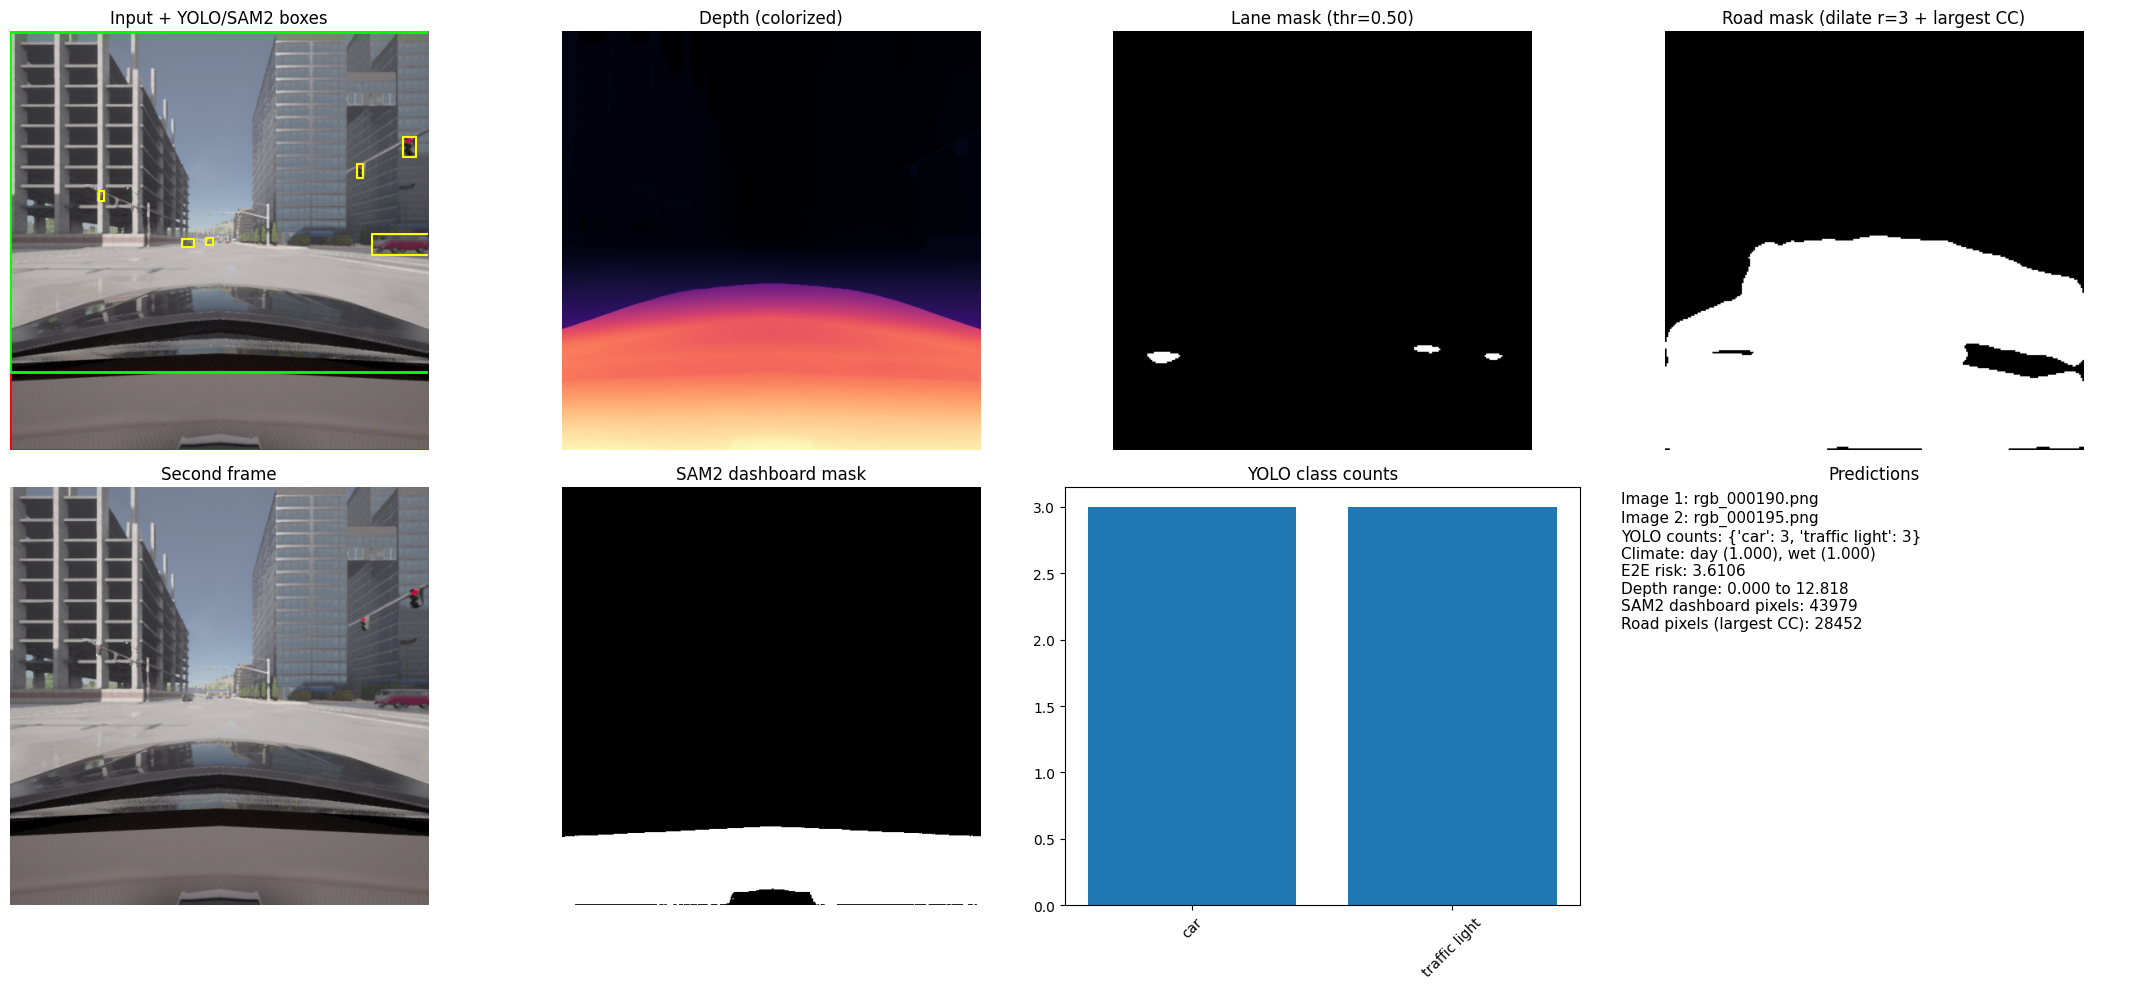

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))

axes[0, 0].imshow(IMAGE_RGB)
axes[0, 0].set_title("Input + YOLO/SAM2 boxes")
axes[0, 0].axis("off")
for det in yolo_detections:
    axes[0, 0].add_patch(
        patches.Rectangle(
            (det.x1, det.y1),
            det.width,
            det.height,
            linewidth=1.5,
            edgecolor="yellow",
            facecolor="none",
        )
    )
if sam2_result is not None and sam2_result.dashboard_bbox is not None:
    dash = sam2_result.dashboard_bbox
    axes[0, 0].add_patch(
        patches.Rectangle(
            (dash.x1, dash.y1),
            dash.width,
            dash.height,
            linewidth=2.0,
            edgecolor="red",
            facecolor="none",
        )
    )
if sam2_result is not None and sam2_result.inverse_bbox is not None:
    inv = sam2_result.inverse_bbox
    axes[0, 0].add_patch(
        patches.Rectangle(
            (inv.x1, inv.y1),
            inv.width,
            inv.height,
            linewidth=2.0,
            edgecolor="lime",
            facecolor="none",
        )
    )

if depth_colored is not None:
    axes[0, 1].imshow(depth_colored)
    axes[0, 1].set_title("Depth (colorized)")
else:
    axes[0, 1].text(0.5, 0.5, "Depth unavailable", ha="center", va="center")
    axes[0, 1].set_title("Depth")
axes[0, 1].axis("off")

if lane_mask is not None:
    axes[0, 2].imshow(lane_mask, cmap="gray")
    axes[0, 2].set_title(f"Lane mask (thr={seg_threshold:.2f})")
else:
    axes[0, 2].text(0.5, 0.5, "Lane mask unavailable", ha="center", va="center")
    axes[0, 2].set_title("Lane mask")
axes[0, 2].axis("off")

if road_mask is not None:
    axes[0, 3].imshow(road_mask, cmap="gray")
    axes[0, 3].set_title("Road mask (dilate r=3 + largest CC)")
else:
    axes[0, 3].text(0.5, 0.5, "Road mask unavailable", ha="center", va="center")
    axes[0, 3].set_title("Road mask")
axes[0, 3].axis("off")

axes[1, 0].imshow(np.asarray(IMAGE2_RGB))
axes[1, 0].set_title("Second frame")
axes[1, 0].axis("off")

if sam2_result is not None:
    axes[1, 1].imshow(sam2_result.dashboard_mask, cmap="gray")
    axes[1, 1].set_title("SAM2 dashboard mask")
else:
    axes[1, 1].text(0.5, 0.5, "SAM2 unavailable", ha="center", va="center")
    axes[1, 1].set_title("SAM2")
axes[1, 1].axis("off")

if yolo_counts:
    labels = list(yolo_counts.keys())
    values = [yolo_counts[k] for k in labels]
    axes[1, 2].bar(labels, values)
    axes[1, 2].set_title("YOLO class counts")
    axes[1, 2].tick_params(axis="x", rotation=45)
else:
    axes[1, 2].text(0.5, 0.5, "No YOLO detections", ha="center", va="center")
    axes[1, 2].set_title("YOLO class counts")

summary = [
    f"Image 1: {IMAGE_PATH.name}",
    f"Image 2: {IMAGE2_PATH.name}",
    f"YOLO counts: {yolo_counts if yolo_counts else '{}'}",
]
if climate_prediction is not None:
    summary.append(
        "Climate: "
        f"{climate_prediction.day_night_label} ({climate_prediction.day_night_confidence:.3f}), "
        f"{climate_prediction.climate_label} ({climate_prediction.climate_confidence:.3f})"
    )
else:
    summary.append("Climate: unavailable")

if risk_prediction is not None and risk_prediction.ready and risk_prediction.latest_risk is not None:
    summary.append(f"E2E risk: {risk_prediction.latest_risk:.4f}")
else:
    summary.append("E2E risk: unavailable")

if depth_prediction is not None:
    summary.append(
        f"Depth range: {depth_prediction.min_depth:.3f} to {depth_prediction.max_depth:.3f}"
    )
if sam2_result is not None:
    summary.append(f"SAM2 dashboard pixels: {sam2_result.selected_area}")
if road_mask is not None:
    summary.append(f"Road pixels (largest CC): {int(np.sum(road_mask))}")

axes[1, 3].axis("off")
axes[1, 3].set_title("Predictions")
axes[1, 3].text(0.01, 0.99, "\n".join(summary), ha="left", va="top", fontsize=11)

plt.tight_layout()
plt.show()

## Phase Correlation (Global Ego-Motion)
This section computes a lightweight CPU-friendly global shift estimate between two frames.
The estimator returns `(bg_flow_x, bg_flow_y)`.

Phase correlation bg_flow: x=-0.3150, y=-0.1155, strength=0.3355 (time=5.31 ms)


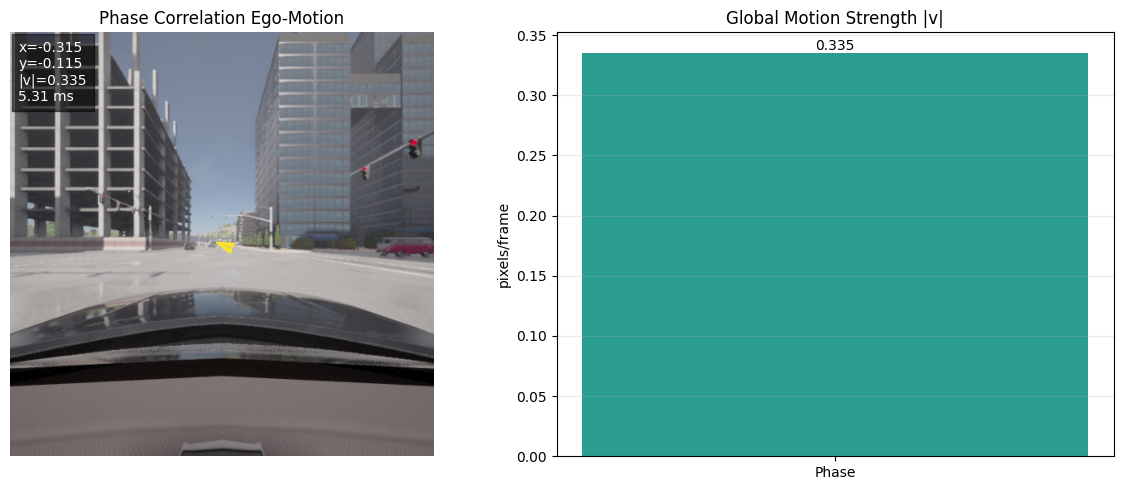

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt

from MIREIA.perception.flow import EgoMotionEstimator

frame1_np = np.asarray(IMAGE_RGB, dtype=np.uint8)
frame2_np = np.asarray(IMAGE2_RGB, dtype=np.uint8)

ego_motion_estimator = EgoMotionEstimator(crop_ratio=0.9)

t0 = time.perf_counter()
bg_flow_x, bg_flow_y = ego_motion_estimator.estimate_motion(frame1_np, frame2_np)
phase_time_ms = (time.perf_counter() - t0) * 1000.0
phase_strength = float(np.hypot(bg_flow_x, bg_flow_y))

print(
    f"Phase correlation bg_flow: x={bg_flow_x:.4f}, y={bg_flow_y:.4f}, "
    f"strength={phase_strength:.4f} (time={phase_time_ms:.2f} ms)"
)

h, w = frame1_np.shape[:2]
cx, cy = w / 2.0, h / 2.0

phase_ratio = min(1.0, phase_strength / max(phase_strength, 1e-6))
phase_arrow_scale = 8.0 + 16.0 * phase_ratio
phase_line_width = max(1.0, min(h, w) * (0.0015 + 0.003 * phase_ratio))
phase_head_width = max(6.0, min(h, w) * (0.015 + 0.01 * phase_ratio))
phase_head_length = max(8.0, min(h, w) * (0.02 + 0.02 * phase_ratio))
phase_color = plt.cm.viridis(phase_ratio)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(frame1_np)
axes[0].set_title("Phase Correlation Ego-Motion")
axes[0].axis("off")
axes[0].arrow(
    cx,
    cy,
    bg_flow_x * phase_arrow_scale,
    bg_flow_y * phase_arrow_scale,
    color=phase_color,
    width=phase_line_width,
    head_width=phase_head_width,
    head_length=phase_head_length,
    length_includes_head=True,
    alpha=0.95,
)
axes[0].text(
    0.02,
    0.98,
    f"x={bg_flow_x:.3f}\ny={bg_flow_y:.3f}\n|v|={phase_strength:.3f}\n{phase_time_ms:.2f} ms",
    transform=axes[0].transAxes,
    va="top",
    ha="left",
    color="white",
    bbox={"facecolor": "black", "alpha": 0.55, "pad": 5},
)

axes[1].bar(["Phase"], [phase_strength], color=["#2a9d8f"])
axes[1].set_title("Global Motion Strength |v|")
axes[1].set_ylabel("pixels/frame")
axes[1].grid(axis="y", alpha=0.25)
axes[1].text(0, phase_strength, f"{phase_strength:.3f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

## YOLOv11 ByteTrack Demo (ID Persistence)
This demo tracks objects on Image 1 and then Image 2 with `persist=True` enabled via `track_objects(...)`.
If tracking works, object IDs should repeat across the two frames for the same objects.

In [ ]:
from ultralytics import YOLO

from MIREIA.perception.flow import track_objects

if not CHECKPOINTS["yolo"].is_file():
    print(f"YOLO checkpoint not found: {CHECKPOINTS['yolo']}")
else:
    yolo_tracker_model = YOLO(str(CHECKPOINTS["yolo"]))

    frame1_np = np.asarray(IMAGE_RGB, dtype=np.uint8)
    frame2_np = np.asarray(IMAGE2_RGB, dtype=np.uint8)

    tracked_frame1 = track_objects(model=yolo_tracker_model, frame_rgb=frame1_np)
    tracked_frame2 = track_objects(model=yolo_tracker_model, frame_rgb=frame2_np)

    ids_frame1 = {obj["id"] for obj in tracked_frame1}
    ids_frame2 = {obj["id"] for obj in tracked_frame2}
    repeated_ids = sorted(ids_frame1.intersection(ids_frame2))

    print(f"Tracked objects in frame 1: {len(tracked_frame1)}")
    print(f"Tracked objects in frame 2: {len(tracked_frame2)}")
    print(f"Repeated IDs across both frames: {repeated_ids if repeated_ids else 'none'}")

    print("\nFrame 1 preview:")
    for obj in tracked_frame1[:5]:
        print(obj)

    print("\nFrame 2 preview:")
    for obj in tracked_frame2[:5]:
        print(obj)

    yolo_track_demo = {
        "frame1": tracked_frame1,
        "frame2": tracked_frame2,
        "repeated_ids": repeated_ids,
    }

Tracked objects in frame 1: 5
Tracked objects in frame 2: 2
Repeated IDs across both frames: [1, 4]

Frame 1 preview:
{'id': 1, 'bbox': [443.32452392578125, 247.47372436523438, 511.8504943847656, 272.80511474609375], 'class': 2}
{'id': 2, 'bbox': [480.474609375, 128.83840942382812, 496.4310607910156, 152.51795959472656], 'class': 9}
{'id': 3, 'bbox': [424.6583251953125, 161.64898681640625, 431.9311828613281, 178.39845275878906], 'class': 9}
{'id': 4, 'bbox': [210.33030700683594, 252.68634033203125, 224.9810791015625, 263.53851318359375], 'class': 2}
{'id': 5, 'bbox': [239.21792602539062, 252.51878356933594, 248.5271453857422, 260.7418212890625], 'class': 2}

Frame 2 preview:
{'id': 1, 'bbox': [444.239501953125, 247.70761108398438, 512.0, 273.3031311035156], 'class': 2}
{'id': 4, 'bbox': [210.06520080566406, 253.28578186035156, 224.58538818359375, 264.0437316894531], 'class': 2}
